In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip -q uninstall -y hdbscan umap-learn numba llvmlite bertopic pandas numpy

!pip -q install -U pip setuptools wheel

# Colab-compatible pins
!pip -q install --no-cache-dir "numpy==2.0.0" "pandas==2.2.2"

# UMAP stack (numba must match numpy<2.1)
!pip -q install --no-cache-dir "numba==0.60.0" "llvmlite==0.43.0" "umap-learn"

# BERTopic + HDBSCAN
!pip -q install --no-cache-dir "hdbscan>=0.8.29" "bertopic==0.17.4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.0 requires numba<1,>0.57, which is not installed.
pytensor 2.38.0 requires numpy>=2.0, which is not installed.
tensorboard 2.19.0 requires numpy>=1.12.0, which is not installed.
fastai 2.8.7 requires pandas, which is not installed.
arviz 0.22.0 requires numpy>=1.26.0, which is not installed.
arviz 0.22.0 requires pandas>=2.1.0, which is not installed.
osqp 1.1.1 requires numpy>=1.7, which is not installed.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, which is not installed.
spacy 3.8.11 requires numpy>=1.19.0; python_version >= "3.9", which is not installed.
torchvision 0.25.0+cpu requires numpy, which is not installed.
pymc 5.28.0 requires nump

In [3]:
import numpy as np, pandas as pd
import numba
from umap import UMAP
import hdbscan
from bertopic import BERTopic

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("numba:", numba.__version__)
print("hdbscan:", hdbscan.__file__)
print("bertopic:", BERTopic)

numpy: 2.0.2
pandas: 2.2.2
numba: 0.60.0
hdbscan: /usr/local/lib/python3.12/dist-packages/hdbscan/__init__.py
bertopic: <class 'bertopic._bertopic.BERTopic'>


In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

In [5]:
model_path = "/content/drive/MyDrive/nlp/final project/bertopic_model_sample.pkl"

topic_model = BERTopic.load(model_path)

print("Loaded BERTopic model from:", model_path)

Loaded BERTopic model from: /content/drive/MyDrive/nlp/final project/bertopic_model_sample.pkl


In [6]:
print(topic_model.get_topic_info().head())

   Topic  Count                                            Name  \
0     -1   8461            -1_opens new_opens_new window_window   
1      0   1495   0_prnewswire_country music_2023 prnewswire_dc   
2      1    626               1_donate_programs_air playing_npr   
3      2    517  2_entertain ment_ment_transportation_entertain   
4      3    508                    3_gpt_chatgpt_chatbot_openai   

                                      Representation  \
0  [opens new, opens, new window, window, traded,...   
1  [prnewswire, country music, 2023 prnewswire, d...   
2  [donate, programs, air playing, npr, 00 00, sc...   
3  [entertain ment, ment, transportation, enterta...   
4  [gpt, chatgpt, chatbot, openai, users, chatbot...   

                                 Representative_Docs  
0  [Elon Musk says he’ll create ‘TruthGPT’ to cou...  
1  [SAP and Google Cloud Enhance Open Data Cloud ...  
2  [Yuval Noah Harari warns AI may mean the end o...  
3  [planetRE Announces AI Intellectual A

In [7]:
info = topic_model.get_topic_info().copy()
info = info[info["Topic"] != -1].copy()

bertopic_table = pd.DataFrame({
    "topic_id": info["Topic"].astype(int),
    "count": info["Count"].astype(int),
    "top_words": info["Representation"].apply(
        lambda words: ", ".join(words[:8]) if isinstance(words, list) else str(words)
    ),
    "rep_snippets": info["Representative_Docs"].apply(
        lambda docs: docs[0][:100] + "..." if isinstance(docs, list) and len(docs) > 0 else ""
    )
})

bertopic_table = bertopic_table.sort_values("count", ascending=False).reset_index(drop=True)

display(bertopic_table.head(20))

,topic_id,count,top_words,rep_snippets
0,0,1495,"prnewswire, country music, 2023 prnewswire, dc...",SAP and Google Cloud Enhance Open Data Cloud W...
1,1,626,"donate, programs, air playing, npr, 00 00, sch...",Yuval Noah Harari warns AI may mean the end of...
2,2,517,"entertain ment, ment, transportation, entertai...",planetRE Announces AI Intellectual Assistant w...
3,3,508,"gpt, chatgpt, chatbot, openai, users, chatbots...",5 simple ChatGPT cheat codes to help you get b...
4,4,460,"cancer, disease, channels, drug, fierce, medic...",MCRA Announces Launch of Integrated AI & Imagi...
5,5,400,"republic, congo, presswire, ein presswire, isl...",Stem Tronics Launches the First Artificial Int...
6,6,390,"oil energy, europe arab, asia africa, mena, ar...",Ecomanager AI Joins Fastercapital's Raise Capi...
7,7,278,"india, minister, indian, india ai, modi, delhi...",India and EU Forge Deeper Ties in AI and Digit...
8,8,275,"outdoors, rawpixel, px 300, jpeg, px, 300, ima...",Firework fireworks outdoors night. AI | Premiu...
9,9,275,"galaxy, samsung, pixel, s24, samsung galaxy, g...",Google Workspace gets new generative AI featur...


In [8]:
save_path_csv = "/content/drive/MyDrive/nlp/final project/clean_base_dataset.csv"
df = pd.read_csv(save_path_csv)

df = df[df["clean_text"].fillna("").str.len() >= 200].copy()
df["clean_text"] = df["clean_text"].fillna("").astype(str)

def light_clean_for_bertopic(text: str) -> str:
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_bt"] = df["clean_text"].apply(light_clean_for_bertopic)

SAMPLE_N = 25000
RANDOM_STATE = 42
MAX_CHARS = 2000
MIN_CHARS = 200

df_clean = df[df["text_bt"].astype(str).str.len() > MIN_CHARS].copy()

df_model = df_clean.sample(
    n=min(SAMPLE_N, len(df_clean)),
    random_state=RANDOM_STATE
).copy()

documents = [t[:MAX_CHARS] for t in df_model["text_bt"].tolist()]
print("documents:", len(documents))

#  Get topic assignments for these documents (NO retraining)
topics, probs = topic_model.transform(documents)

#  Your topic share block ---
df_model["topic_id"] = topics

topic_counts = df_model[df_model["topic_id"] != -1]["topic_id"].value_counts()
topic_share = (topic_counts / (df_model["topic_id"] != -1).sum()).sort_values(ascending=False)

topic_share_df = topic_share.reset_index()
topic_share_df.columns = ["topic_id", "doc_share"]
display(topic_share_df.head(15))

# Your “rows -> bertopic_table” block (fixed to use N correctly) ---
topic_info = topic_model.get_topic_info()              # Topic, Count, Name, etc.
rep_docs = topic_model.get_representative_docs()       # dict: topic_id -> list[str]

rows = []
N = (df_model["topic_id"] != -1).sum()  # share among non-outliers (matches your earlier share logic)

for _, r in topic_info.iterrows():
    tid = int(r["Topic"])
    if tid == -1:
        continue

    # Use df_model-derived counts so they match THIS run (not whatever was stored in the model)
    cnt = int((df_model["topic_id"] == tid).sum())

    words = topic_model.get_topic(tid) or []
    top_words = [w for w, _ in words[:12]]

    reps = rep_docs.get(tid, [])
    reps = [str(x).replace("\n", " ")[:260] + "..." for x in reps[:3]]

    rows.append({
        "topic_id": tid,
        "doc_count": cnt,
        "doc_share": cnt / N if N else 0.0,
        "top_words": ", ".join(top_words),
        "rep_snippets": " | ".join(reps)
    })

bertopic_table = (
    pd.DataFrame(rows)
    .sort_values("doc_count", ascending=False)
    .reset_index(drop=True)
)

display(bertopic_table.head(20))

documents: 25000


Batches:   0%|          | 0/782 [00:00<?, ?it/s]

,topic_id,doc_share
0,0,0.073347
1,1,0.040250
2,2,0.033617
3,3,0.030691
4,4,0.029911
5,5,0.026009
6,6,0.023213
7,9,0.017686
8,8,0.017166
9,11,0.016061


,topic_id,doc_count,doc_share,top_words,rep_snippets
0,0,1128,0.073347,"prnewswire, country music, 2023 prnewswire, dc...",SAP and Google Cloud Enhance Open Data Cloud W...
1,1,619,0.040250,"donate, programs, air playing, npr, 00 00, sch...",Yuval Noah Harari warns AI may mean the end of...
2,2,517,0.033617,"entertain ment, ment, transportation, entertai...",planetRE Announces AI Intellectual Assistant w...
3,3,472,0.030691,"gpt, chatgpt, chatbot, openai, users, chatbots...",5 simple ChatGPT cheat codes to help you get b...
4,4,460,0.029911,"cancer, disease, channels, drug, fierce, medic...",MCRA Announces Launch of Integrated AI & Imagi...
5,5,400,0.026009,"republic, congo, presswire, ein presswire, isl...",Stem Tronics Launches the First Artificial Int...
6,6,357,0.023213,"oil energy, europe arab, asia africa, mena, ar...",Ecomanager AI Joins Fastercapital's Raise Capi...
7,9,272,0.017686,"galaxy, samsung, pixel, s24, samsung galaxy, g...",Google Workspace gets new generative AI featur...
8,8,264,0.017166,"outdoors, rawpixel, px 300, jpeg, px, 300, ima...",Firework fireworks outdoors night. AI | Premiu...
9,11,247,0.016061,"bitcoin, crypto, token, meme, tokens, mexc, de...",The escalation of tensions in the Middle East ...


In [9]:
import re
import pandas as pd
import numpy as np
from collections import Counter
import spacy

#  Use  LDA labels as the industry taxonomy (fixed buckets)
topic_labels_lda = {
    0: "Healthcare & Clinical AI",
    1: "Newswire / Distribution (noise)",
    2: "Broadcast / Radio / Programming (noise)",
    3: "AI Chips & Financial Markets",
    4: "AI Tools & Applications",
    5: "Crypto & AI Trading",
    6: "Enterprise IT & Digital Transformation",
    7: "Non-English / Mixed (noise)",
    8: "Jobs & Data Science Workforce",
    9: "AI Investment Content",
    10: "Education & Opinion",
    11: "Consumer Tech & Devices",
    12: "Entertainment / Media (noise)",
    13: "Cloud Platforms & Enterprise Solutions",
    14: "Generative AI Images & Creative Tools",
    15: "Finance & Investment",
    16: "ChatGPT & AI Assistants",
    17: "OpenAI & Big Tech AI Industry",
    18: "Local News / Weather (noise)",
    19: "Cybersecurity & AI Risk"
}

# Create a set of allowed "industry buckets" (excluding noise will be done later)
INDUSTRY_BUCKETS = set(topic_labels_lda.values())

def norm(s: str) -> str:
    return re.sub(r"\s+", " ", str(s).lower()).strip()

# Keyword rules that map BERTopic top_words -> LDA industry bucket
#    (Edit these to match your BERTopic topics; start broad, then refine)
INDUSTRY_RULES = [
    ("Healthcare & Clinical AI", [
        "clinical", "patient", "medical", "health", "hospital", "diagnosis", "diagnostic",
        "imaging", "cancer", "drug", "disease", "radiology", "therapy", "biotech", "pharma"
    ]),
    ("AI Chips & Financial Markets", [
        "chip", "gpu", "semiconductor", "nvidia", "amd", "intel", "cuda", "hardware", "accelerator"
    ]),
    ("AI Tools & Applications", [
        "tool", "model", "api", "feature", "agentic", "agent", "workflow", "integration",
        "platform", "productivity", "automation"
    ]),
    ("Crypto & AI Trading", [
        "crypto", "bitcoin", "token", "coin", "wallet", "exchange", "mexc", "defi"
    ]),
    ("Enterprise IT & Digital Transformation", [
        "enterprise", "it", "software", "saas", "migration", "data center", "architecture",
        "transformation", "infrastructure", "deployment"
    ]),
    ("Jobs & Data Science Workforce", [
        "job", "hiring", "career", "salary", "workforce", "resume", "data scientist",
        "interview", "skills"
    ]),
    ("AI Investment Content", [
        "set to change", "top ai stock", "best ai stock", "investing in ai", "ai stocks to buy",
        "newsletter", "pick", "watchlist"
    ]),
    ("Education & Opinion", [
        "school", "student", "teacher", "university", "education", "essay", "opinion",
        "philosophy", "consciousness", "ethics", "society"
    ]),
    ("Consumer Tech & Devices", [
        "samsung", "pixel", "iphone", "galaxy", "device", "smartphone", "apple", "android"
    ]),
    ("Cloud Platforms & Enterprise Solutions", [
        "cloud", "aws", "azure", "gcp", "google cloud", "sap", "oracle", "workspace",
        "data cloud", "open data cloud"
    ]),
    ("Generative AI Images & Creative Tools", [
        "image", "generate", "prompt", "photo", "art", "midjourney", "stable diffusion",
        "adobe", "design"
    ]),
    ("Finance & Investment", [
        "nasdaq", "nyse", "stock", "share", "market", "earnings", "investor", "fund",
        "portfolio", "trading", "price"
    ]),
    ("ChatGPT & AI Assistants", [
        "chatgpt", "gpt", "chatbot", "assistant", "prompt", "copilot", "claude"
    ]),
    ("OpenAI & Big Tech AI Industry", [
        "openai", "microsoft", "google", "meta", "anthropic", "gemini", "sam altman"
    ]),
    ("Cybersecurity & AI Risk", [
        "security", "attack", "breach", "risk", "threat", "malware", "phishing", "vulnerability"
    ]),
    # Noise buckets (keep at end so “real” industries win if tied)
    ("Newswire / Distribution (noise)", [
        "prnewswire", "presswire", "ein presswire", "distribution", "globenewswire"
    ]),
    ("Broadcast / Radio / Programming (noise)", [
        "radio", "program", "air playing", "schedule", "npr"
    ]),
    ("Entertainment / Media (noise)", [
        "video", "song", "music", "watch video", "live breaking"
    ]),
    ("Local News / Weather (noise)", [
        "weather", "local", "outdoors", "hour", "forecast"
    ]),
]

def map_bertopic_to_industry(top_words: str) -> str:
    tw = norm(top_words)
    best_label = "Enterprise IT & Digital Transformation"  # default fallback (or "Other / Mixed")
    best_hits = 0

    for label, kws in INDUSTRY_RULES:
        hits = sum(1 for kw in kws if kw in tw)
        if hits > best_hits:
            best_hits = hits
            best_label = label

    # If absolutely nothing matches, mark as mixed
    if best_hits == 0:
        return "Other / Mixed"
    return best_label

#  Apply mapping to your BERTopic table
#    Assumes: bertopic_table has [topic_id, count/doc_count, top_words, rep_snippets]
bertopic_table = bertopic_table.copy()

# handle if your column name is doc_count instead of count
if "count" not in bertopic_table.columns and "doc_count" in bertopic_table.columns:
    bertopic_table["count"] = bertopic_table["doc_count"]

bertopic_table["industry_auto"] = bertopic_table["top_words"].apply(map_bertopic_to_industry)

# manual_override = {0: "Newswire / Distribution (noise)", 10: "Cloud Platforms & Enterprise Solutions"}
manual_override = {}

bertopic_table["industry"] = bertopic_table.apply(
    lambda r: manual_override.get(int(r["topic_id"]), r["industry_auto"]),
    axis=1
)

display(bertopic_table[["topic_id", "count", "top_words", "industry"]].head(25))

# Join topic assignments back to documents and compute industry exposure
#    Assumes: df_model["topic_id"] already exists from BERTopic fit_transform
topic_to_industry = dict(zip(bertopic_table["topic_id"].astype(int), bertopic_table["industry"]))

df_model = df_model.copy()
df_model["industry"] = df_model["topic_id"].map(topic_to_industry)
df_model.loc[df_model["topic_id"] == -1, "industry"] = "Outlier / Unclustered"

# Exclude outliers
df_assigned = df_model[df_model["topic_id"] != -1].copy()

industry_counts = df_assigned["industry"].value_counts()
industry_share = (industry_counts / len(df_assigned)).rename("doc_share")

industry_exposure = (
    pd.concat([industry_counts.rename("doc_count"), industry_share], axis=1)
    .reset_index()
    .rename(columns={"index": "industry"})
    .sort_values("doc_share", ascending=False)
)
display(industry_exposure)

#  Filter out noise industries using your LDA taxonomy
NOISE_INDUSTRIES = {
    "Newswire / Distribution (noise)",
    "Broadcast / Radio / Programming (noise)",
    "Non-English / Mixed (noise)",
    "Entertainment / Media (noise)",
    "Local News / Weather (noise)",
    "Outlier / Unclustered",
    "Other / Mixed"
}

industry_exposure_focus = industry_exposure[~industry_exposure["industry"].isin(NOISE_INDUSTRIES)]
display(industry_exposure_focus)

# Top companies per industry (ORG from title)
nlp_ner = spacy.load("en_core_web_sm")

def extract_orgs(text):
    doc = nlp_ner(str(text))
    return [ent.text for ent in doc.ents if ent.label_ == "ORG"]

df_assigned["orgs"] = df_assigned["title"].apply(extract_orgs)

rows = []
for ind in industry_exposure_focus["industry"]:
    sub = df_assigned[df_assigned["industry"] == ind]
    orgs_flat = [org for lst in sub["orgs"] for org in lst]
    for org, cnt in Counter(orgs_flat).most_common(15):
        rows.append({"industry": ind, "company": org, "mention_count": cnt})

industry_company_table = pd.DataFrame(rows).sort_values(
    ["industry", "mention_count"], ascending=[True, False]
)
display(industry_company_table.head(50))

,topic_id,count,top_words,industry
0,0,1128,"prnewswire, country music, 2023 prnewswire, dc...",Newswire / Distribution (noise)
1,1,619,"donate, programs, air playing, npr, 00 00, sch...",Broadcast / Radio / Programming (noise)
2,2,517,"entertain ment, ment, transportation, entertai...",Other / Mixed
3,3,472,"gpt, chatgpt, chatbot, openai, users, chatbots...",ChatGPT & AI Assistants
4,4,460,"cancer, disease, channels, drug, fierce, medic...",Healthcare & Clinical AI
5,5,400,"republic, congo, presswire, ein presswire, isl...",Newswire / Distribution (noise)
6,6,357,"oil energy, europe arab, asia africa, mena, ar...",Generative AI Images & Creative Tools
7,9,272,"galaxy, samsung, pixel, s24, samsung galaxy, g...",Consumer Tech & Devices
8,8,264,"outdoors, rawpixel, px 300, jpeg, px, 300, ima...",Generative AI Images & Creative Tools
9,11,247,"bitcoin, crypto, token, meme, tokens, mexc, de...",Crypto & AI Trading


,industry,doc_count,doc_share
0,Other / Mixed,2723,0.177060
1,Enterprise IT & Digital Transformation,2315,0.150530
2,Newswire / Distribution (noise),1609,0.104623
3,Generative AI Images & Creative Tools,1573,0.102282
4,Healthcare & Clinical AI,920,0.059822
5,AI Chips & Financial Markets,896,0.058261
6,Finance & Investment,798,0.051889
7,Broadcast / Radio / Programming (noise),649,0.042200
8,ChatGPT & AI Assistants,622,0.040445
9,Entertainment / Media (noise),576,0.037454


,industry,doc_count,doc_share
1,Enterprise IT & Digital Transformation,2315,0.150530
3,Generative AI Images & Creative Tools,1573,0.102282
4,Healthcare & Clinical AI,920,0.059822
5,AI Chips & Financial Markets,896,0.058261
6,Finance & Investment,798,0.051889
8,ChatGPT & AI Assistants,622,0.040445
10,OpenAI & Big Tech AI Industry,523,0.034007
11,AI Tools & Applications,437,0.028415
12,Crypto & AI Trading,427,0.027765
13,Consumer Tech & Devices,380,0.024709


,industry,company,mention_count
45,AI Chips & Financial Markets,AI,72
46,AI Chips & Financial Markets,Computer Weekly,28
47,AI Chips & Financial Markets,Intel,26
48,AI Chips & Financial Markets,Nvidia,21
49,AI Chips & Financial Markets,Apple,19
50,AI Chips & Financial Markets,Microsoft,19
51,AI Chips & Financial Markets,AMD,19
52,AI Chips & Financial Markets,NASDAQ,14
53,AI Chips & Financial Markets,NYSE,13
54,AI Chips & Financial Markets,Huawei,11


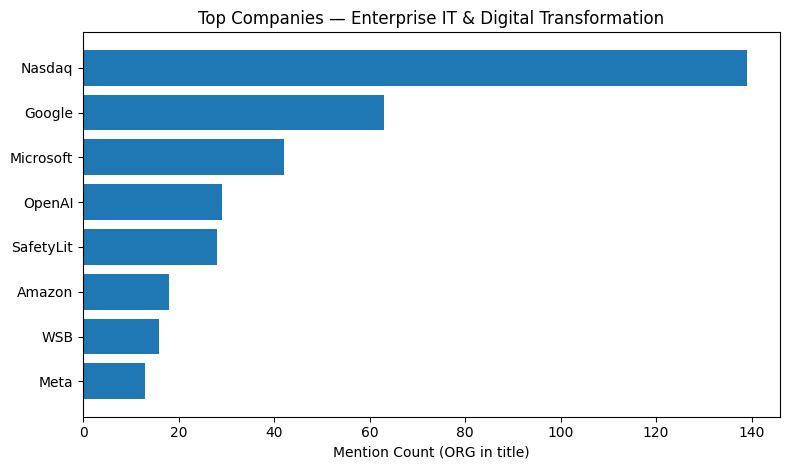

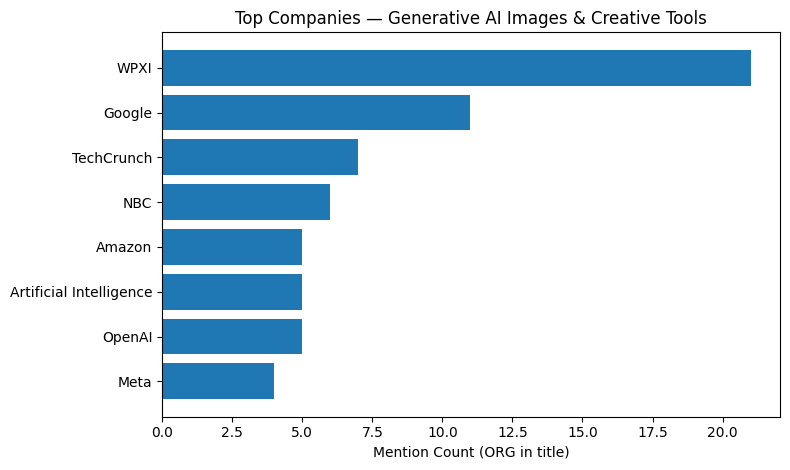

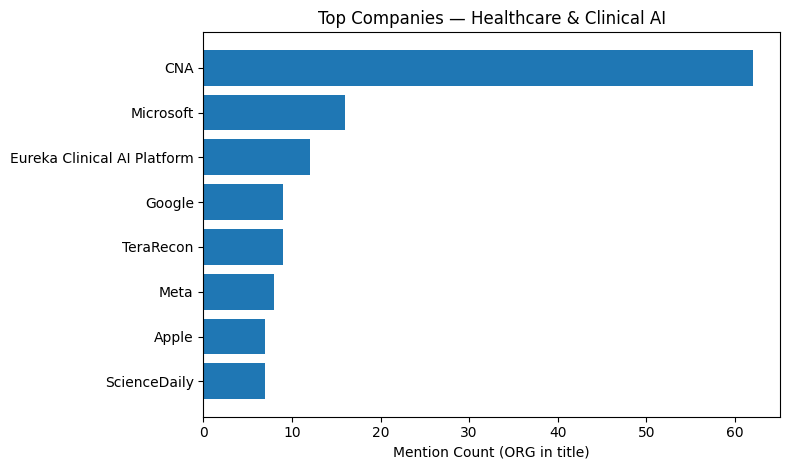

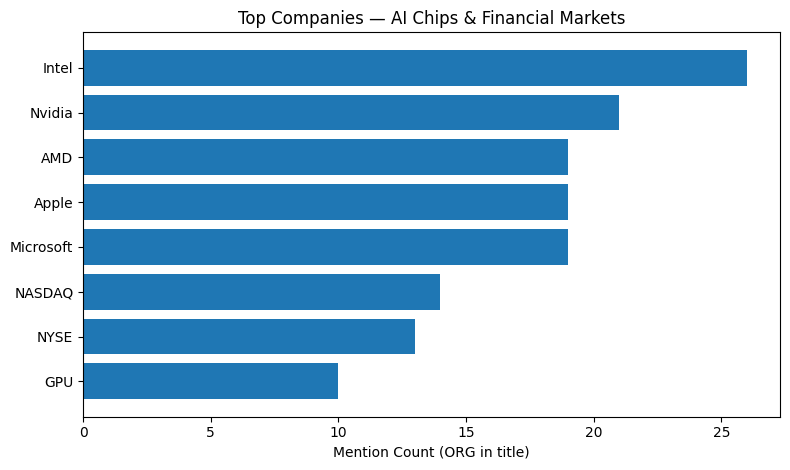

,industry,doc_count,doc_share
1,Enterprise IT & Digital Transformation,2315,0.150530
3,Generative AI Images & Creative Tools,1573,0.102282
4,Healthcare & Clinical AI,920,0.059822
5,AI Chips & Financial Markets,896,0.058261


In [10]:
import re

# --- helper: filter out fake/non-company entities in the company list ---
JUNK_EXACT = {
    "Premium Photo", "Premium Photo Illustration",
    "Navigation Search Please", "Industry News", "TextShare", "Home News News",
    "Major News", "Region American Europe Arab World",
    "Invest", "GMT", "AI"
}

JUNK_PAT = re.compile(
    r"(premium photo|illustration|navigation|search|subscribe|cookie|privacy|terms|newsletter|"
    r"\bnews\b|\bradio\b|\btimes\b|\bweekly\b|press|media|journal|magazine|"
    r"\.com\b|\.net\b|\.org\b)",
    re.IGNORECASE
)

# allowlist for valid single-word orgs that might otherwise be removed
ALLOWLIST = {
    "Microsoft","Google","OpenAI","Apple","Amazon","Meta","IBM","Intel","Nvidia","AMD",
    "Nasdaq","NYSE","Chevron"
}

def looks_like_company(name: str) -> bool:
    n = str(name).strip()
    if not n or len(n) < 2:
        return False

    # exact junk
    if n in JUNK_EXACT:
        return False

    # pattern junk (publishers/boilerplate/domains)
    if JUNK_PAT.search(n):
        return n in ALLOWLIST

    # region/menu labels
    if n.lower().startswith("region "):
        return False

    # too long => usually menu/header text
    if len(n.split()) > 5:
        return False

    # remove obvious time abbreviations
    if n.lower() in {"gmt", "utc", "est", "pst"}:
        return False

    # remove generic finance words
    if n.lower() in {"invest", "investment", "fund", "market"}:
        return False

    # remove person-like single names (keep allowlist)
    if len(n.split()) == 1 and n.istitle() and n not in ALLOWLIST:
        return False

    return True


# 2) FOUR GRAPHS: Top companies for the top 4 industries (filtered)
topN_companies = 8
n_industries_to_plot = 4

top_industries = (
    industry_exposure_focus
    .sort_values("doc_share", ascending=False)
    .head(n_industries_to_plot)["industry"]
    .tolist()
)

for ind in top_industries:
    comp_df = (
        industry_company_table[industry_company_table["industry"] == ind]
        .copy()
    )

    # FILTER OUT FAKE / NON-COMPANY NAMES HERE
    comp_df = comp_df[comp_df["company"].apply(looks_like_company)].copy()

    # (optional) remove very low-frequency one-offs
    # comp_df = comp_df[comp_df["mention_count"] >= 3]

    # recompute top N after filtering
    comp_df = (
        comp_df.sort_values("mention_count", ascending=False)
              .head(topN_companies)
              .sort_values("mention_count", ascending=True)
              .copy()
    )

    if comp_df.empty:
        print(f"[WARN] No valid company ORG entities found for industry: {ind}")
        continue

    plt.figure(figsize=(8, 4.8))
    plt.barh(comp_df["company"], comp_df["mention_count"])
    plt.xlabel("Mention Count (ORG in title)")
    plt.title(f"Top Companies — {ind}")
    plt.tight_layout()
    plt.show()


display(
    industry_exposure_focus
    .sort_values("doc_share", ascending=False)
    .head(n_industries_to_plot)[["industry", "doc_count", "doc_share"]]
)

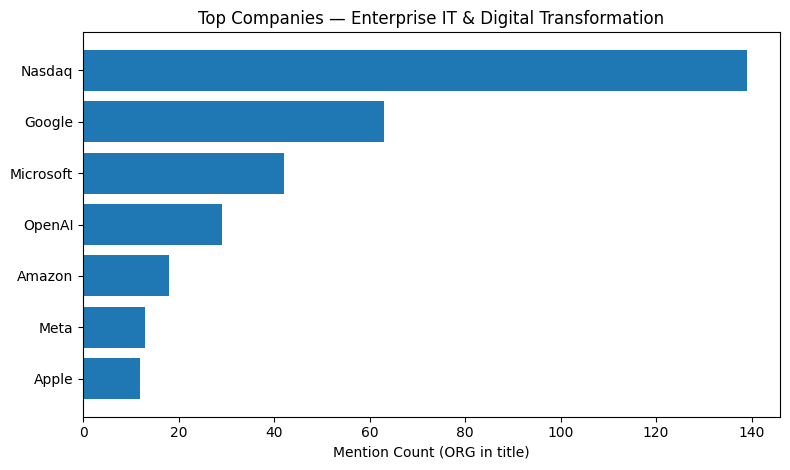

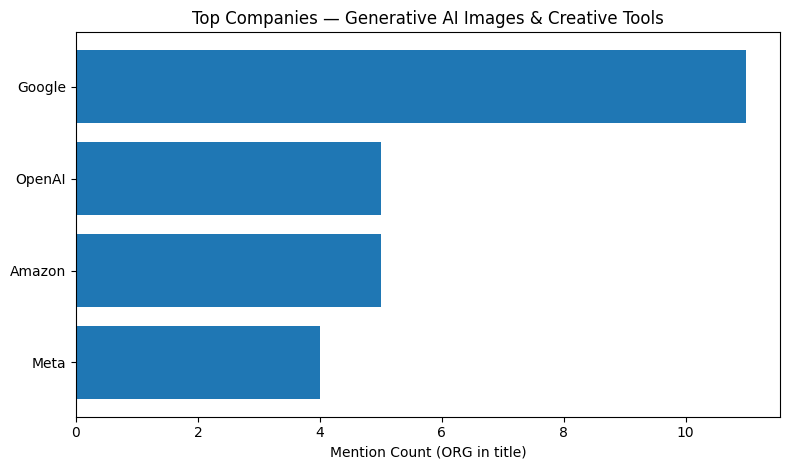

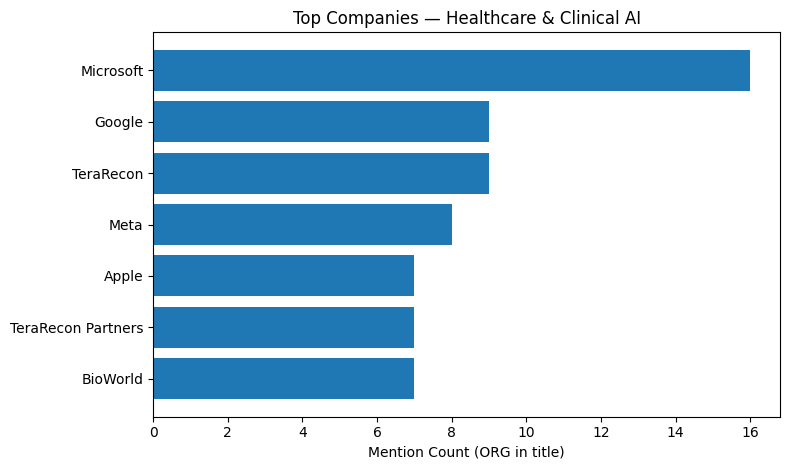

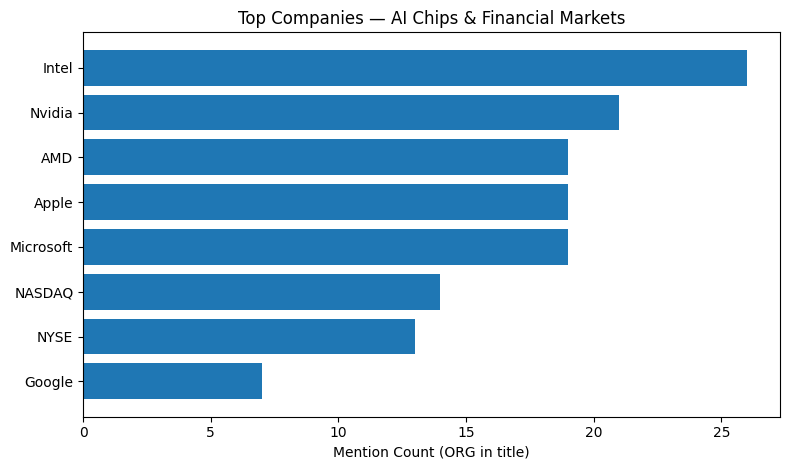

,industry,doc_count,doc_share
1,Enterprise IT & Digital Transformation,2315,0.150530
3,Generative AI Images & Creative Tools,1573,0.102282
4,Healthcare & Clinical AI,920,0.059822
5,AI Chips & Financial Markets,896,0.058261


In [11]:
import re

# ----------------------------
# 1) Stronger filters
# ----------------------------

# Exact junk / non-companies you already saw in charts
JUNK_EXACT = {
    # crawl artifacts
    "Premium Photo", "Premium Photo Illustration",
    "Navigation Search Please", "Industry News", "TextShare", "Home News News",
    "Major News", "Region American Europe Arab World",
    # generic words / non-org
    "AI", "Artificial Intelligence", "GPU", "Invest", "GMT",
    # publishers/media that slipped in
    "TechCrunch", "NBC", "CNA", "ScienceDaily", "WPXI",
    # other non-company org-like strings
    "SafetyLit", "WSB", "Eureka Clinical AI Platform"
}

# Generic patterns that indicate "not a company"
# (publishers, domains, UI text, obvious non-company keywords)
JUNK_PAT = re.compile(
    r"(premium photo|illustration|navigation|search|subscribe|cookie|privacy|terms|newsletter|"
    r"\bnews\b|\bradio\b|\btimes\b|\bweekly\b|press|media|journal|magazine|"
    r"\bplatform\b|\bchannel\b|\bstation\b|\bdaily\b|"
    r"\.com\b|\.net\b|\.org\b)",
    re.IGNORECASE
)

# Allowlist: legit single-token orgs (prevents over-filtering)
ALLOWLIST = {
    "Microsoft","Google","OpenAI","Apple","Amazon","Meta","IBM","Intel","Nvidia","AMD",
    "Nasdaq","NYSE","Chevron"
}

# Optional: remove “exchange-like” orgs if you only want operating companies
EXCLUDE_EXCHANGES = False
EXCHANGES = {"Nasdaq", "NASDAQ", "NYSE"}

def looks_like_company(name: str) -> bool:
    n = str(name).strip()
    if not n or len(n) < 2:
        return False

    # remove exact junk
    if n in JUNK_EXACT:
        return False

    # optionally remove stock exchanges if you don’t want them in “companies”
    if EXCLUDE_EXCHANGES and n in EXCHANGES:
        return False

    n_low = n.lower()

    # remove menu/region labels
    if n_low.startswith("region "):
        return False

    # remove time abbreviations
    if n_low in {"gmt", "utc", "est", "pst"}:
        return False

    # remove generic finance words
    if n_low in {"invest", "investment", "fund", "market"}:
        return False

    # remove pattern-based junk (publishers/domains/UI)
    if JUNK_PAT.search(n):
        return n in ALLOWLIST

    # remove very long phrases (usually headers, boilerplate)
    if len(n.split()) > 5:
        return False

    # remove person-like single names (keep allowlist)
    if len(n.split()) == 1 and n.istitle() and n not in ALLOWLIST:
        return False

    return True


# ----------------------------
# 2) FOUR GRAPHS (same logic, now cleaner)
# ----------------------------
topN_companies = 8
n_industries_to_plot = 4

top_industries = (
    industry_exposure_focus
    .sort_values("doc_share", ascending=False)
    .head(n_industries_to_plot)["industry"]
    .tolist()
)

for ind in top_industries:
    comp_df = industry_company_table[industry_company_table["industry"] == ind].copy()

    #  filter here
    comp_df = comp_df[comp_df["company"].apply(looks_like_company)].copy()

    # optional: remove very low-frequency one-offs
    # comp_df = comp_df[comp_df["mention_count"] >= 3]

    comp_df = (
        comp_df.sort_values("mention_count", ascending=False)
              .head(topN_companies)
              .sort_values("mention_count", ascending=True)
              .copy()
    )

    if comp_df.empty:
        print(f"[WARN] No valid company ORG entities found for industry: {ind}")
        continue

    plt.figure(figsize=(8, 4.8))
    plt.barh(comp_df["company"], comp_df["mention_count"])
    plt.xlabel("Mention Count (ORG in title)")
    plt.title(f"Top Companies — {ind}")
    plt.tight_layout()
    plt.show()

display(
    industry_exposure_focus
    .sort_values("doc_share", ascending=False)
    .head(n_industries_to_plot)[["industry", "doc_count", "doc_share"]]
)

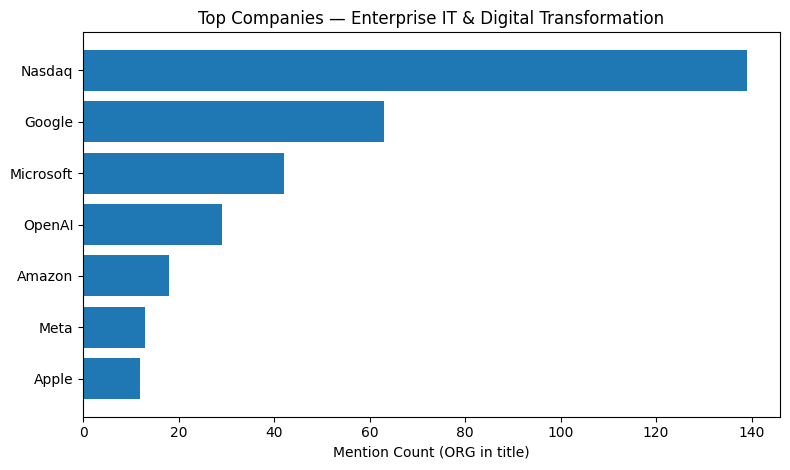

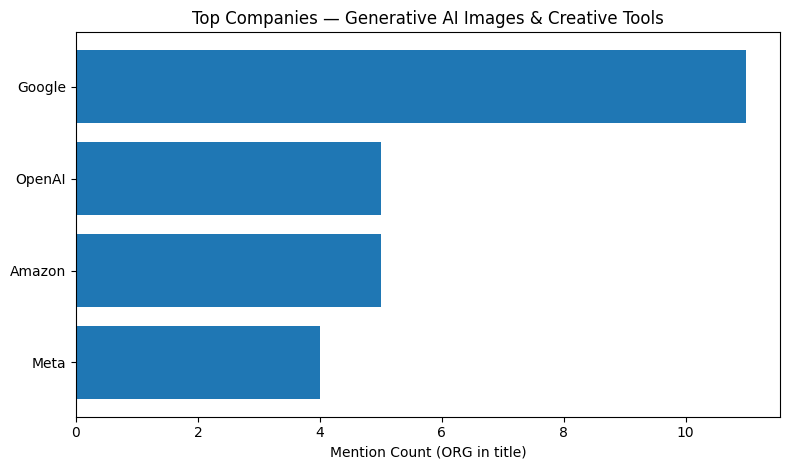

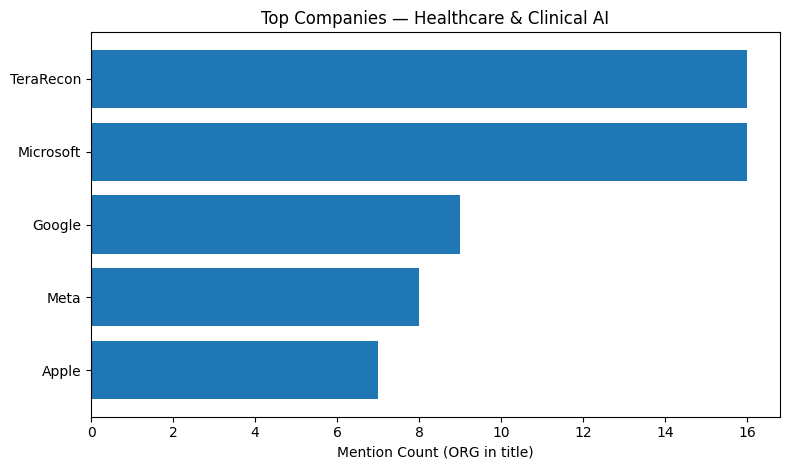

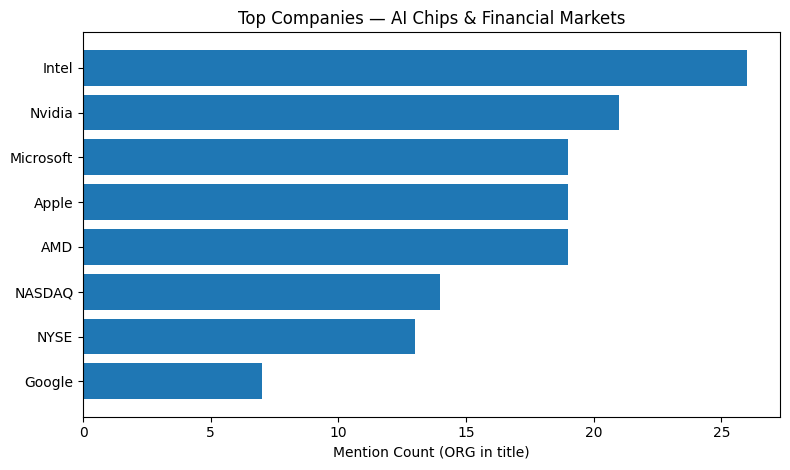

,industry,doc_count,doc_share
1,Enterprise IT & Digital Transformation,2315,0.150530
3,Generative AI Images & Creative Tools,1573,0.102282
4,Healthcare & Clinical AI,920,0.059822
5,AI Chips & Financial Markets,896,0.058261


In [12]:
import re
import matplotlib.pyplot as plt

# ----------------------------
# 1) Filters + canonicalization
# ----------------------------

JUNK_EXACT = {
    "Premium Photo", "Premium Photo Illustration",
    "Navigation Search Please", "Industry News", "TextShare", "Home News News",
    "Major News", "Region American Europe Arab World",
    "AI", "Artificial Intelligence", "GPU", "Invest", "GMT",
    "TechCrunch", "NBC", "CNA", "ScienceDaily", "WPXI",
    "SafetyLit", "WSB", "Eureka Clinical AI Platform"
}

# Add BioWorld if you want "companies only" (recommended)
EXCLUDE_MEDIA_OUTLETS = True
MEDIA_EXACT = {"BioWorld", "ScienceDaily", "TechCrunch", "NBC", "CNA", "WPXI"}

JUNK_PAT = re.compile(
    r"(premium photo|illustration|navigation|search|subscribe|cookie|privacy|terms|newsletter|"
    r"\bnews\b|\bradio\b|\btimes\b|\bweekly\b|press|media|journal|magazine|"
    r"\bplatform\b|\bchannel\b|\bstation\b|\bdaily\b|"
    r"\.com\b|\.net\b|\.org\b)",
    re.IGNORECASE
)

ALLOWLIST = {
    "Microsoft","Google","OpenAI","Apple","Amazon","Meta","IBM","Intel","Nvidia","AMD",
    "Nasdaq","NYSE","Chevron","TeraRecon"
}

EXCLUDE_EXCHANGES = False
EXCHANGES = {"Nasdaq", "NASDAQ", "NYSE"}

# Canonicalize variants -> one company name
CANON_MAP = {
    "terarecon partners": "TeraRecon",
    "terarecon": "TeraRecon",
}

def canonicalize_company(name: str) -> str:
    n = str(name).strip()
    n_low = n.lower().strip()

    # normalize punctuation/extra spaces
    n_low = re.sub(r"\s+", " ", n_low)

    # map known variants
    if n_low in CANON_MAP:
        return CANON_MAP[n_low]

    # common cleanup: remove corporate suffixes (optional)
    # e.g., "Inc", "LLC" sometimes appear
    n = re.sub(r"\b(inc|llc|ltd|plc|corp|corporation|co)\.?\b", "", n, flags=re.I).strip()
    n = re.sub(r"\s+", " ", n).strip()

    return n

def looks_like_company(name: str) -> bool:
    n = str(name).strip()
    if not n or len(n) < 2:
        return False

    # optionally exclude media outlets (BioWorld etc.)
    if EXCLUDE_MEDIA_OUTLETS and n in MEDIA_EXACT:
        return False

    if n in JUNK_EXACT:
        return False

    if EXCLUDE_EXCHANGES and n in EXCHANGES:
        return False

    n_low = n.lower()

    if n_low.startswith("region "):
        return False

    if n_low in {"gmt", "utc", "est", "pst"}:
        return False

    if n_low in {"invest", "investment", "fund", "market"}:
        return False

    if JUNK_PAT.search(n):
        return n in ALLOWLIST

    if len(n.split()) > 5:
        return False

    # remove person-like single names (keep allowlist)
    if len(n.split()) == 1 and n.istitle() and n not in ALLOWLIST:
        return False

    return True


# ----------------------------
# 2) FOUR GRAPHS (clean + merge variants)
# ----------------------------
topN_companies = 8
n_industries_to_plot = 4

top_industries = (
    industry_exposure_focus
    .sort_values("doc_share", ascending=False)
    .head(n_industries_to_plot)["industry"]
    .tolist()
)

for ind in top_industries:
    comp_df = industry_company_table[industry_company_table["industry"] == ind].copy()

    #  canonicalize first (merges variants like "TeraRecon Partners" -> "TeraRecon")
    comp_df["company"] = comp_df["company"].apply(canonicalize_company)

    # regroup counts after canonicalization
    comp_df = (
        comp_df.groupby(["industry", "company"], as_index=False)["mention_count"]
        .sum()
    )

    # filter companies
    comp_df = comp_df[comp_df["company"].apply(looks_like_company)].copy()

    # optional: remove very low-frequency one-offs
    # comp_df = comp_df[comp_df["mention_count"] >= 3]

    # select top N
    comp_df = (
        comp_df.sort_values("mention_count", ascending=False)
              .head(topN_companies)
              .sort_values("mention_count", ascending=True)
              .copy()
    )

    if comp_df.empty:
        print(f"[WARN] No valid company ORG entities found for industry: {ind}")
        continue

    plt.figure(figsize=(8, 4.8))
    plt.barh(comp_df["company"], comp_df["mention_count"])
    plt.xlabel("Mention Count (ORG in title)")
    plt.title(f"Top Companies — {ind}")
    plt.tight_layout()
    plt.show()

display(
    industry_exposure_focus
    .sort_values("doc_share", ascending=False)
    .head(n_industries_to_plot)[["industry", "doc_count", "doc_share"]]
)